# Unsupervised GMM clustering — welded CR-39 tracks

Same pipeline as [`gmm_nn_unsup_4.py`](gmm_nn_unsup_4.py): ROI threshold → morphological closing (welding) → contour features → GMM.

This notebook adds **full per-cluster statistics** and **evaluation plots** (montages, t-SNE, silhouette, spatial overlays) modelled on Step 3 of `algorithms/radon_track_nn.ipynb`.

## Step 0 — Setup, configuration and image I/O

In [1]:
import sys
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

GMM_DIR = Path.cwd() if (Path.cwd() / "gmm_nn_unsup_4.py").exists() else Path.cwd() / "gmm"
if str(GMM_DIR) not in sys.path:
    sys.path.insert(0, str(GMM_DIR))

from gmm_nn_unsup_4 import Config, extract_features_from_roi, cluster_colors_rgb

cfg = Config()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

PATCH_SIZE = 48
MONTAGE_N = 24
MONTAGE_COLS = 8
ROI_WINDOW = 700
# Fixed ROI for cross-run comparison (5.6b)
COMPARE_ROI_IMAGE = "LBS255612.jpg"
COMPARE_ROI_X0 = 200
COMPARE_ROI_Y0 = 400
FOCUS_CLUSTER = 1  # single-cluster spatial plot after fig2
FOCUS_CMAP = "turbo"  # continuous colormap; scales to large event counts
CLUSTER_CMAP = "tab20"  # vivid cluster colours for any cfg.n_clusters

np.random.seed(cfg.random_state)

image_paths = sorted(cfg.data_dir.glob(cfg.image_glob))
print(f"data_dir: {cfg.data_dir}")
print(f"output_dir: {cfg.output_dir}")
print(f"images: {len(image_paths)} matching {cfg.image_glob}")
if image_paths:
    print("  first:", image_paths[0].name)

data_dir: /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/data_test
output_dir: /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs
images: 15 matching LBS*.jpg
  first: LBS255611.jpg


## Step 1 — Feature extraction (welded contours + event registry)

In [2]:
def contour_centroid(cnt):
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        x, y, w, h = cv2.boundingRect(cnt)
        return x + w // 2, y + h // 2
    return int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])


def contour_max_intensity(roi, cnt):
    """Peak raw intensity inside the welded blob mask."""
    x, y, w, h = cv2.boundingRect(cnt)
    sub = roi[y : y + h, x : x + w]
    mask = np.zeros(sub.shape, np.uint8)
    cv2.drawContours(mask, [cnt - [[x, y]]], -1, 1, thickness=cv2.FILLED)
    vals = sub[mask.astype(bool)]
    return float(vals.max()) if vals.size else 0.0


if not image_paths:
    raise FileNotFoundError(f"No files matching {cfg.image_glob} in {cfg.data_dir}")

print("Extracting physical features with spatial coalescence (welding)...")
all_features = []
meta_rows = []
image_registry = []
label_offset = 0

for path in image_paths:
    print(f"  Scanning {path.name}...")
    feats, cnts, roi, debug_thresh = extract_features_from_roi(path, cfg)
    if feats is None:
        continue
    print(f"    -> Extracted {len(feats)} valid events (Area >= {cfg.min_area}px).")
    if cfg.save_debug_images and debug_thresh is not None:
        cv2.imwrite(str(cfg.output_dir / f"debug_binary_{path.stem}.png"), debug_thresh)
    if len(feats) == 0:
        continue
    for i, cnt in enumerate(cnts):
        cx, cy = contour_centroid(cnt)
        meta_rows.append({
            "image": path.name,
            "cx": cx,
            "cy": cy,
            "area": float(feats[i, 0]),
            "perimeter": float(feats[i, 1]),
            "circularity": float(feats[i, 2]),
            "aspect_ratio": float(feats[i, 3]),
            "max_intensity": contour_max_intensity(roi, cnt),
        })
    all_features.append(feats)
    image_registry.append({
        "path": path,
        "counts": len(feats),
        "label_start": label_offset,
        "contours": cnts,
        "roi": roi,
    })
    label_offset += len(feats)

if not all_features:
    raise RuntimeError("CRITICAL ZERO COUNT: The signal is completely empty.")

X = np.vstack(all_features)
meta = pd.DataFrame(meta_rows)
assert len(meta) == len(X)
print(f"\nTotal physical events across {len(image_registry)} images: {len(X)}")

Extracting physical features with spatial coalescence (welding)...
  Scanning LBS255611.jpg...
    -> Extracted 972 valid events (Area >= 20.0px).
  Scanning LBS255612.jpg...
    -> Extracted 894 valid events (Area >= 20.0px).
  Scanning LBS255613.jpg...
    -> Extracted 867 valid events (Area >= 20.0px).
  Scanning LBS255614.jpg...
    -> Extracted 837 valid events (Area >= 20.0px).
  Scanning LBS255615.jpg...
    -> Extracted 855 valid events (Area >= 20.0px).
  Scanning LBS255616.jpg...
    -> Extracted 743 valid events (Area >= 20.0px).
  Scanning LBS255617.jpg...
    -> Extracted 959 valid events (Area >= 20.0px).
  Scanning LBS255618.jpg...
    -> Extracted 792 valid events (Area >= 20.0px).
  Scanning LBS255619.jpg...
    -> Extracted 893 valid events (Area >= 20.0px).
  Scanning LBS255620.jpg...
    -> Extracted 958 valid events (Area >= 20.0px).
  Scanning LBS255621.jpg...
    -> Extracted 908 valid events (Area >= 20.0px).
  Scanning LBS255622.jpg...
    -> Extracted 1007 val

## Step 2 — GMM fit and script-parity exports

Fitting Gaussian Mixture Model with k=8 classes...


/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 


cluster sizes:
cluster
0    3363
1    3228
2    2092
3       4
4    2393
5    2114
6       1
7     308
Name: count, dtype: int64


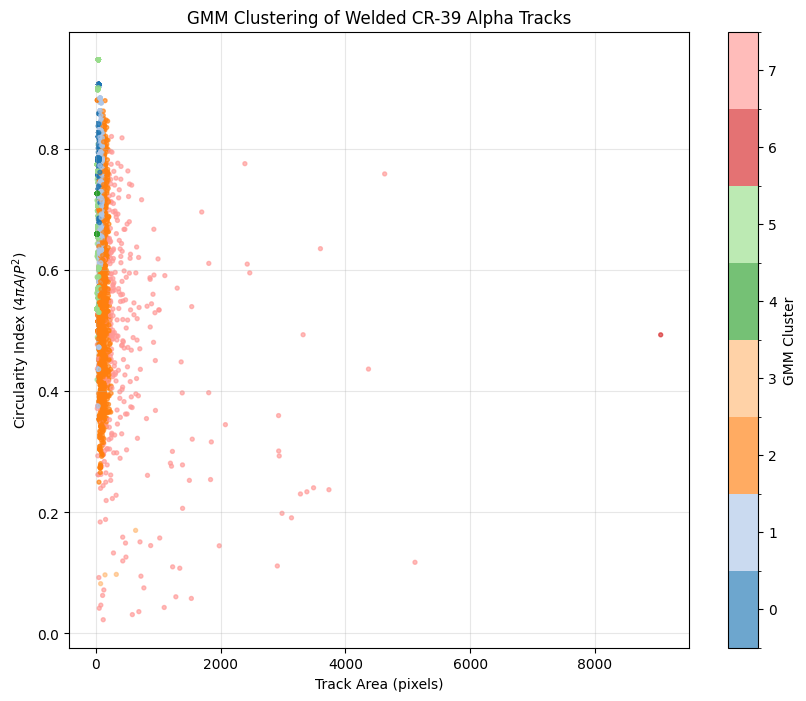

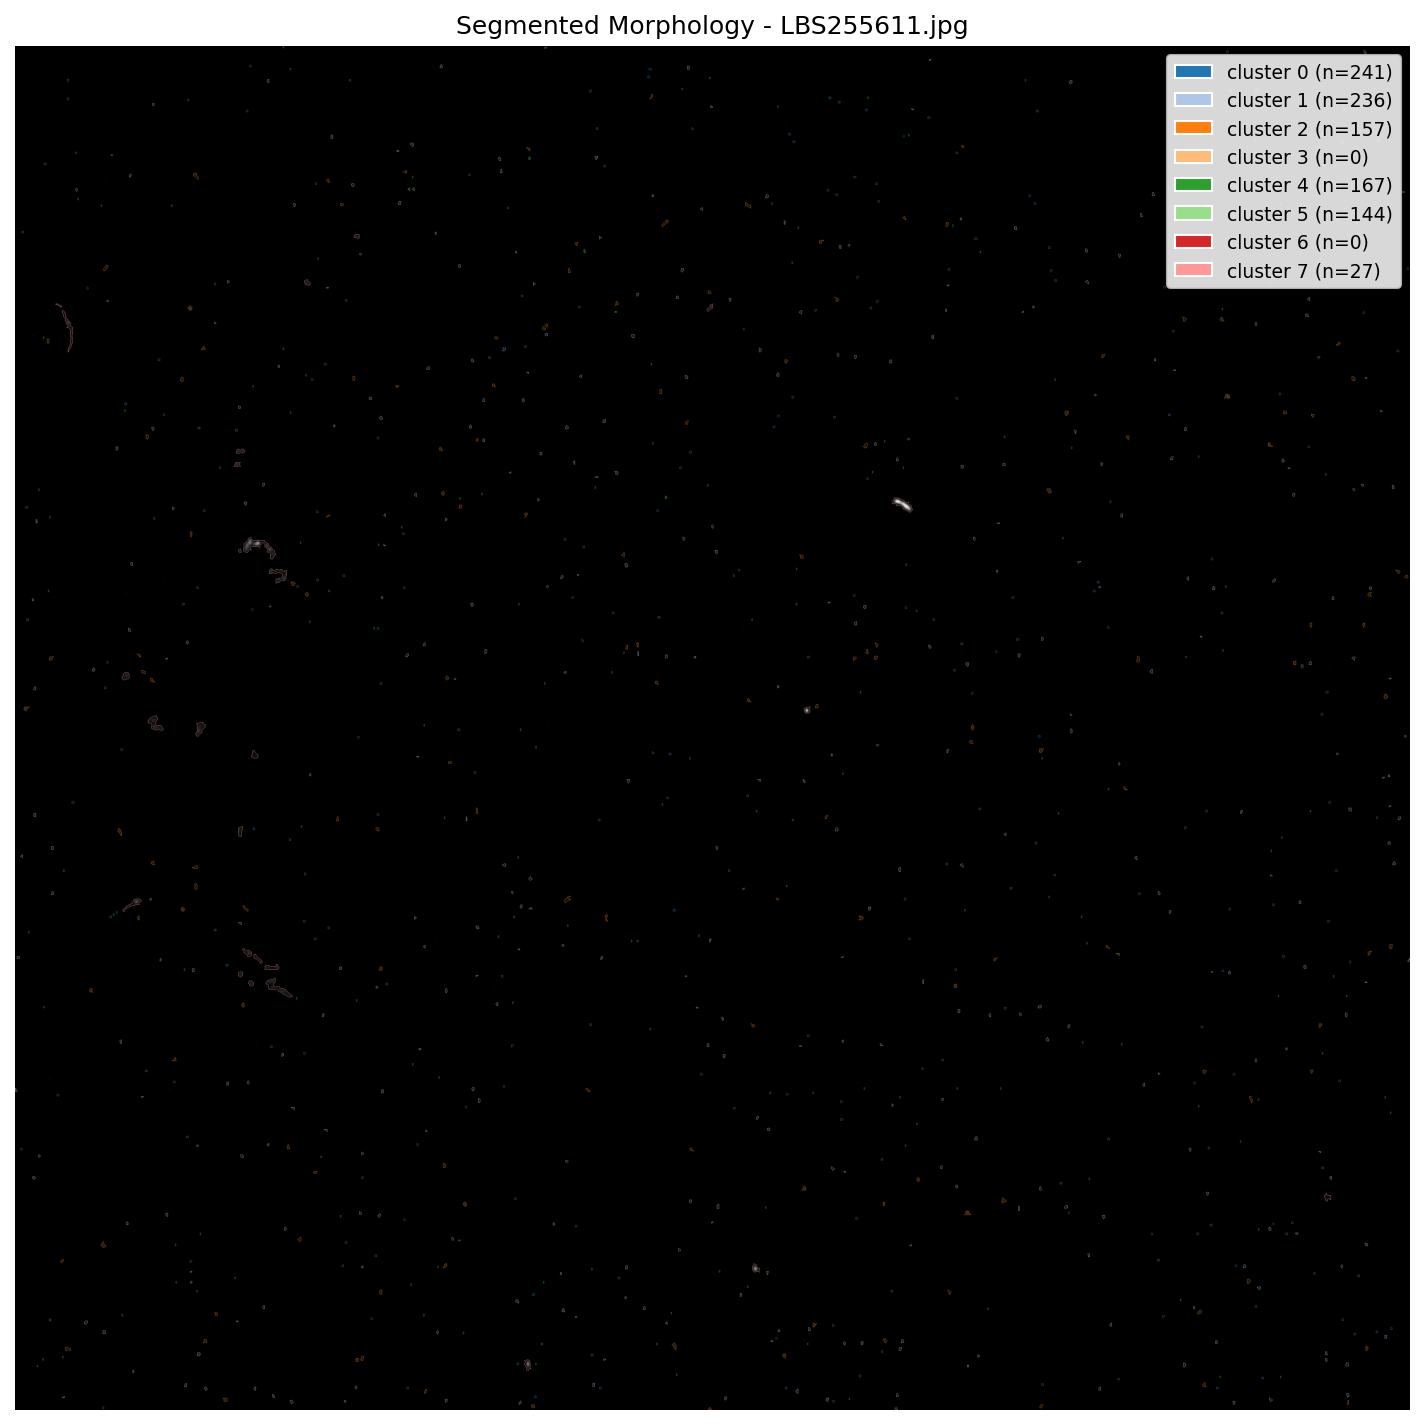

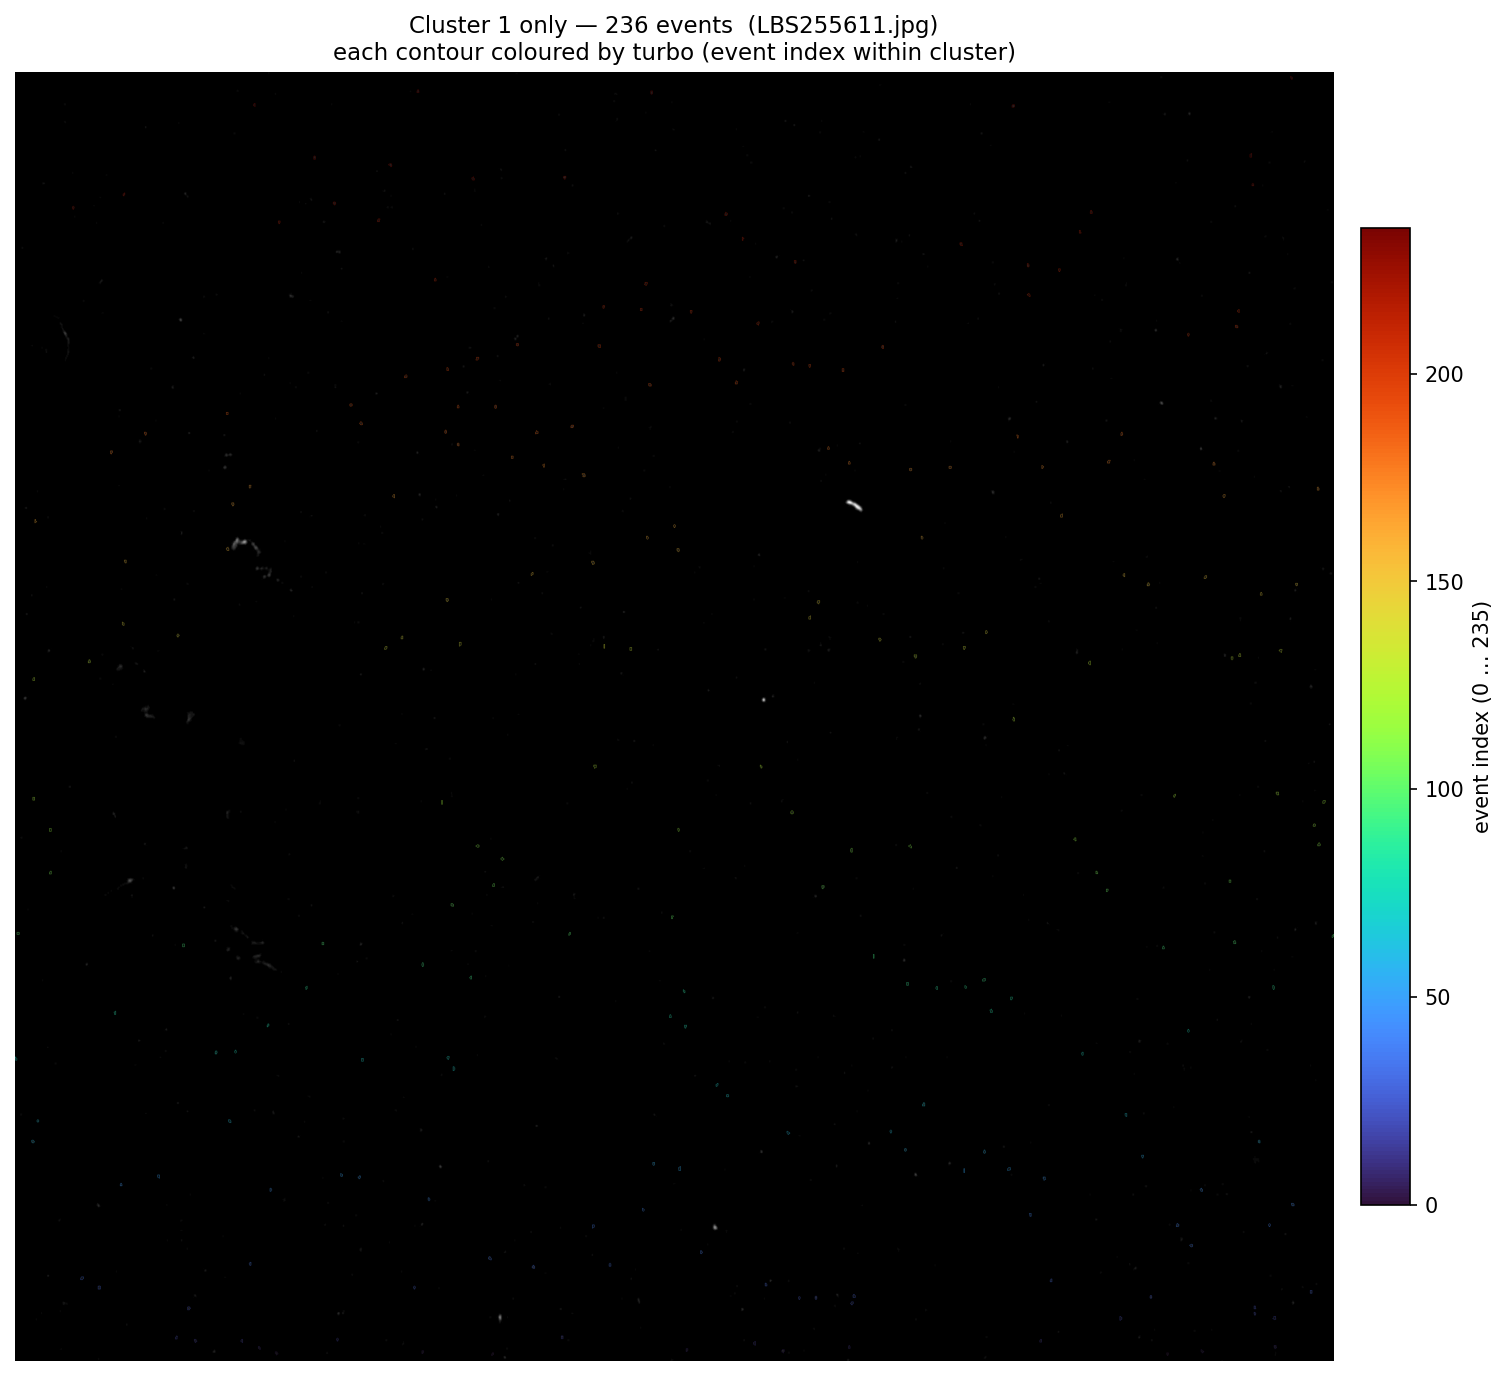

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs/fig2_spatial_mapping_cluster1.png  (236 events)
Saved gmm_model.joblib, fig1, fig2, gmm_cluster_profiles.csv → /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Fitting Gaussian Mixture Model with k={cfg.n_clusters} classes...")
gmm = GaussianMixture(
    n_components=cfg.n_clusters,
    covariance_type="full",
    random_state=cfg.random_state,
)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)
posterior = gmm.predict_proba(X_scaled)

meta = meta.copy()
meta["cluster"] = labels
meta["posterior"] = posterior[np.arange(len(labels)), labels]
K = cfg.n_clusters

print("\ncluster sizes:")
print(meta["cluster"].value_counts().sort_index())

# Shared vivid cluster colours (one distinct colour per cluster)
colors_rgb = cluster_colors_rgb(K, CLUSTER_CMAP)
colors_bgr = [
    (int(b * 255), int(g * 255), int(r * 255)) for r, g, b in colors_rgb
]
_discrete_cmap = ListedColormap(colors_rgb)
_bound_norm = BoundaryNorm(np.arange(K + 1) - 0.5, K)

# Fig 1: feature space (area vs circularity)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X[:, 0],
    X[:, 2],
    c=labels,
    cmap=_discrete_cmap,
    norm=_bound_norm,
    alpha=0.65,
    s=8,
)
plt.xlabel("Track Area (pixels)")
plt.ylabel(r"Circularity Index ($4\pi A / P^2$)")
plt.title("GMM Clustering of Welded CR-39 Alpha Tracks")
plt.colorbar(scatter, label="GMM Cluster", ticks=list(range(K)))
plt.grid(True, alpha=0.3)
plt.savefig(cfg.output_dir / "fig1_feature_space.pdf", bbox_inches="tight")
plt.show()

# Minimal cluster profiles (script parity)
profile_rows = []
for cluster_id in range(K):
    mask = labels == cluster_id
    cluster_feats = X[mask]
    if len(cluster_feats) > 0:
        profile_rows.append({
            "cluster_id": cluster_id,
            "event_count": len(cluster_feats),
            "mean_area_px": float(np.mean(cluster_feats[:, 0])),
            "mean_circularity": float(np.mean(cluster_feats[:, 2])),
            "mean_aspect_ratio": float(np.mean(cluster_feats[:, 3])),
        })
pd.DataFrame(profile_rows).to_csv(cfg.output_dir / "gmm_cluster_profiles.csv", index=False)

# Fig 2: spatial mapping on first image (same cluster colours as fig1)
if image_registry:
    sample = image_registry[0]
    start = sample["label_start"]
    end = start + sample["counts"]
    sample_labels = labels[start:end]
    roi_norm = cv2.normalize(sample["roi"], None, 0, 255, cv2.NORM_MINMAX)
    roi_color = cv2.cvtColor(roi_norm, cv2.COLOR_GRAY2BGR)
    for idx, cnt in enumerate(sample["contours"]):
        c_id = sample_labels[idx]
        cv2.drawContours(roi_color, [cnt], -1, colors_bgr[c_id], 1)
    plt.figure(figsize=(12, 12), dpi=150)
    plt.imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
    plt.title(f"Segmented Morphology - {sample['path'].name}")
    plt.axis("off")
    legend_handles = [
        Patch(
            facecolor=colors_rgb[c],
            edgecolor="white",
            label=f"cluster {c} (n={int((sample_labels == c).sum())})",
        )
        for c in range(K)
    ]
    plt.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.85)
    plt.savefig(cfg.output_dir / "fig2_spatial_mapping.png", bbox_inches="tight")
    plt.show()

    # Fig 2b: one cluster only — each event gets a distinct colormap colour
    focus_idx = np.where(sample_labels == FOCUS_CLUSTER)[0]
    n_focus = len(focus_idx)
    if n_focus == 0:
        print(f"No cluster-{FOCUS_CLUSTER} events on {sample['path'].name}; skip focus plot.")
    else:
        roi_focus = cv2.cvtColor(roi_norm, cv2.COLOR_GRAY2BGR)
        cmap = plt.get_cmap(FOCUS_CMAP)
        for rank, idx in enumerate(focus_idx):
            t = rank / max(n_focus - 1, 1)
            r, g, b, _ = cmap(t)
            bgr = (int(b * 255), int(g * 255), int(r * 255))
            cv2.drawContours(roi_focus, [sample["contours"][idx]], -1, bgr, 1)
        fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
        ax.imshow(cv2.cvtColor(roi_focus, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f"Cluster {FOCUS_CLUSTER} only — {n_focus} events  ({sample['path'].name})\n"
            f"each contour coloured by {FOCUS_CMAP} (event index within cluster)",
            fontsize=11,
        )
        ax.axis("off")
        sm = plt.cm.ScalarMappable(
            cmap=cmap,
            norm=plt.Normalize(vmin=0, vmax=max(n_focus - 1, 1)),
        )
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
        cbar.set_label(f"event index (0 … {n_focus - 1})")
        focus_path = cfg.output_dir / f"fig2_spatial_mapping_cluster{FOCUS_CLUSTER}.png"
        fig.savefig(focus_path, bbox_inches="tight")
        plt.show()
        print(f"Saved {focus_path}  ({n_focus} events)")

joblib.dump({"scaler": scaler, "gmm": gmm}, cfg.output_dir / "gmm_model.joblib")
print(f"Saved gmm_model.joblib, fig1, fig2, gmm_cluster_profiles.csv → {cfg.output_dir}")

## Step 3 — Full per-cluster statistics

,n,pct_total,n_images,area_min,area_mean,area_max,area_std,perimeter_min,perimeter_mean,perimeter_max,...,aspect_ratio_min,aspect_ratio_mean,aspect_ratio_max,aspect_ratio_std,max_intensity_min,max_intensity_mean,max_intensity_max,max_intensity_std,posterior_mean,posterior_min
cluster,,,,,,,,,,,,,,,,,,,,,
0,3363,24.906,15,39.0,48.610,69.5,4.856,24.485,28.013,35.071,...,0.600,0.969,1.500,0.143,1.0,1.623,4.0,0.610,0.990,0.538
1,3228,23.906,15,37.5,76.542,110.0,13.916,28.142,36.792,46.627,...,0.250,0.733,1.222,0.150,1.0,2.602,5.0,0.856,0.962,0.473
2,2092,15.493,15,25.5,102.311,246.0,37.931,19.071,47.837,90.627,...,0.286,0.919,2.000,0.296,1.0,3.083,14.0,1.265,0.969,0.506
3,4,0.030,2,77.0,297.750,638.0,250.347,108.485,167.385,216.971,...,9.429,11.270,13.000,1.643,1.0,8.500,21.0,9.256,1.000,1.000
4,2393,17.722,15,21.0,21.720,28.0,2.126,20.000,20.206,22.000,...,0.500,0.513,0.625,0.038,1.0,1.004,2.0,0.065,1.000,1.000
5,2114,15.656,15,20.0,32.767,51.0,10.195,19.314,24.819,34.243,...,0.333,1.137,2.750,0.452,1.0,1.863,4.0,0.447,0.976,0.533
6,1,0.007,1,9056.0,9056.000,9056.0,NaN,480.250,480.250,480.250,...,0.585,0.585,0.585,NaN,14.0,14.000,14.0,NaN,1.000,1.000
7,308,2.281,15,24.0,621.963,5117.0,795.036,25.657,131.655,739.671,...,0.016,1.164,5.000,0.773,1.0,8.643,71.0,9.884,0.976,0.512


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,total
image,,,,,,,,,
LBS255611.jpg,241,236,157,0,167,144,0,27,972
LBS255612.jpg,229,205,125,0,165,146,0,24,894
LBS255613.jpg,213,218,129,0,152,130,0,25,867
LBS255614.jpg,234,165,129,0,165,129,0,15,837
LBS255615.jpg,209,202,126,0,179,124,0,15,855
LBS255616.jpg,185,165,99,0,156,127,1,10,743
LBS255617.jpg,245,263,158,0,152,130,0,11,959
LBS255618.jpg,194,190,121,0,138,133,0,16,792
LBS255619.jpg,216,189,111,0,179,175,0,23,893


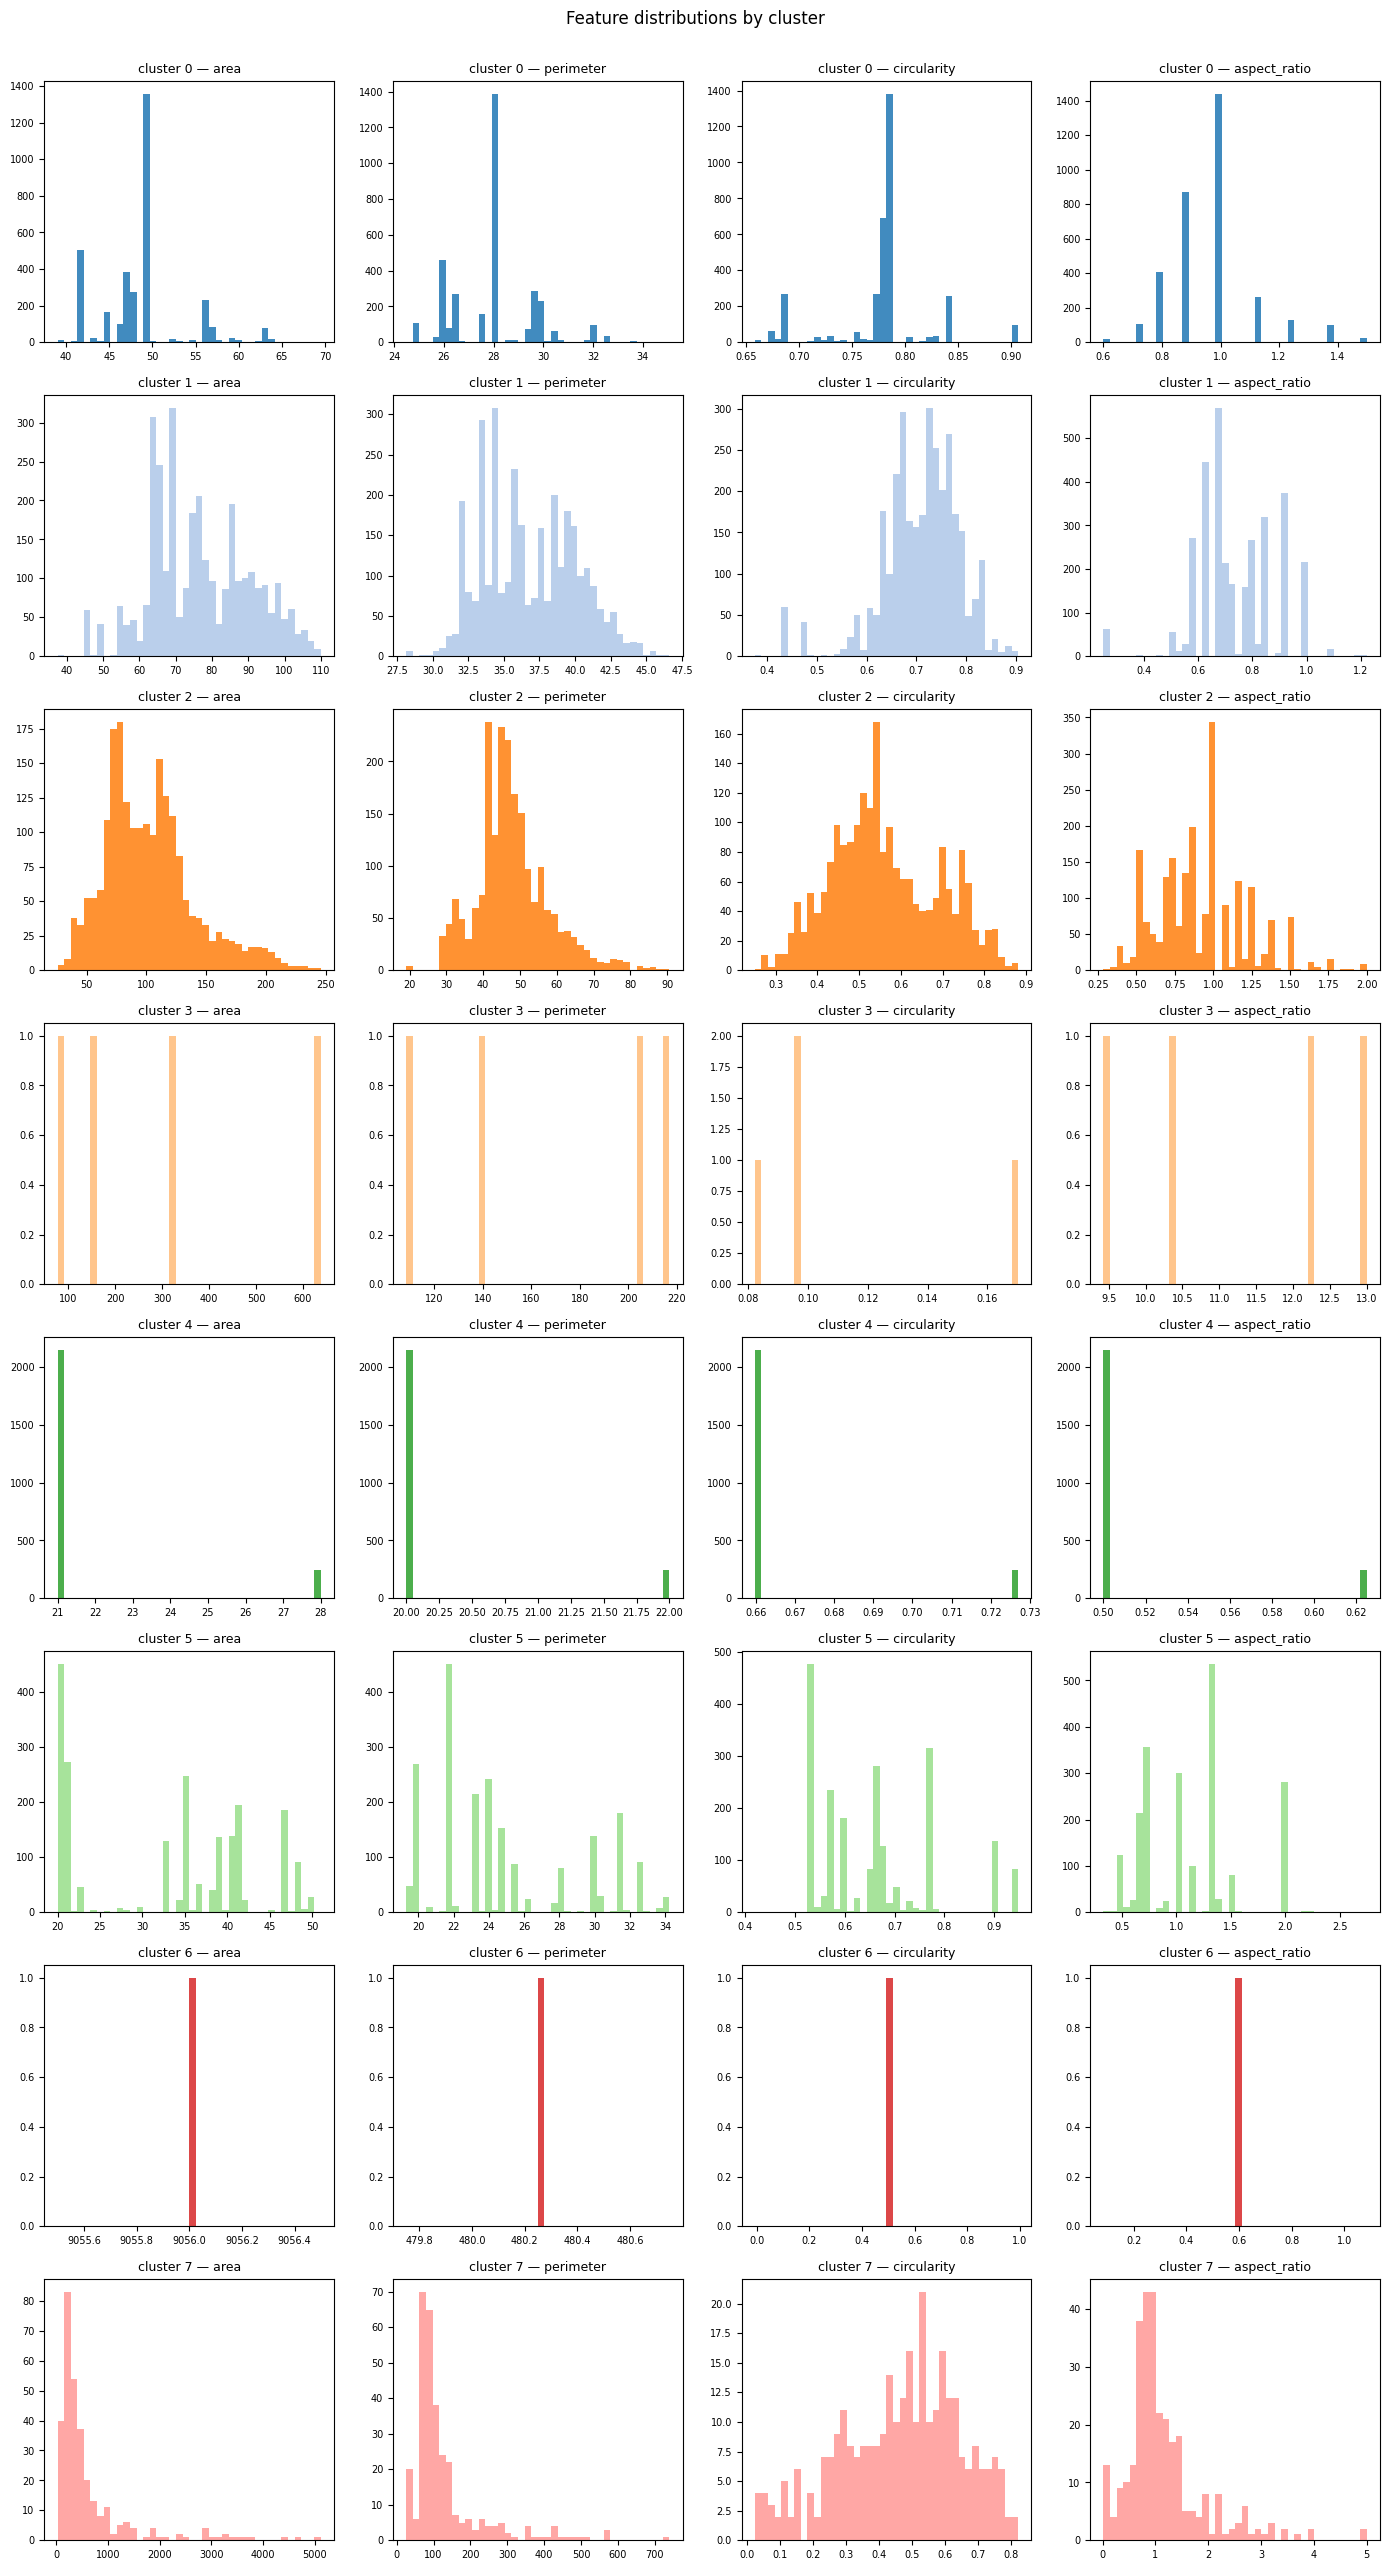

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs/gmm_cluster_profiles_full.csv


In [4]:
FEATURE_COLS = ["area", "perimeter", "circularity", "aspect_ratio"]
STATS_COLS = FEATURE_COLS + ["max_intensity"]
N_TOTAL = len(meta)


def cluster_stats_block(sub, cluster_id):
    """Monospace summary text + flat dict for CSV."""
    n = len(sub)
    pct = 100.0 * n / N_TOTAL if N_TOTAL else 0.0
    n_images = sub["image"].nunique() if n else 0
    lines = [
        f"cluster={cluster_id}  n={n}  ({pct:.1f}% of all)  images={n_images}",
    ]
    row = {
        "cluster": cluster_id,
        "n": n,
        "pct_total": pct,
        "n_images": n_images,
    }
    if n == 0:
        lines.append("(empty cluster)")
        row["posterior_mean"] = np.nan
        row["posterior_min"] = np.nan
        for col in STATS_COLS:
            for stat in ("min", "mean", "max", "std"):
                row[f"{col}_{stat}"] = np.nan
        return "\n".join(lines), row
    for col in STATS_COLS:
        lines.append(
            f"{col:14s} min={sub[col].min():.3f}  mean={sub[col].mean():.3f}  "
            f"max={sub[col].max():.3f}  std={sub[col].std():.3f}"
        )
        row[f"{col}_min"] = float(sub[col].min())
        row[f"{col}_mean"] = float(sub[col].mean())
        row[f"{col}_max"] = float(sub[col].max())
        row[f"{col}_std"] = float(sub[col].std())
    row["posterior_mean"] = float(sub["posterior"].mean())
    row["posterior_min"] = float(sub["posterior"].min())
    lines.append(
        f"posterior:       min={sub['posterior'].min():.3f}  mean={sub['posterior'].mean():.3f}"
    )
    return "\n".join(lines), row


full_profile_rows = []
for c in range(K):
    sub = meta.loc[meta["cluster"] == c]
    _, row = cluster_stats_block(sub, c)
    full_profile_rows.append(row)

profiles_full_df = pd.DataFrame(full_profile_rows).set_index("cluster").sort_index()
profiles_full_df.to_csv(cfg.output_dir / "gmm_cluster_profiles_full.csv")
display(profiles_full_df.round(3))

# Per-image cluster counts
pivot = meta.pivot_table(index="image", columns="cluster", aggfunc="size", fill_value=0)
pivot.columns = [f"cluster_{c}" for c in pivot.columns]
pivot["total"] = pivot.sum(axis=1)
display(pivot)

# Feature histograms per cluster
fig, axes = plt.subplots(K, 4, figsize=(14, 3.2 * K), squeeze=False)
for c in range(K):
    sub = meta.loc[meta["cluster"] == c]
    for j, col in enumerate(FEATURE_COLS):
        ax = axes[c, j]
        if len(sub):
            ax.hist(sub[col], bins=40, color=colors_rgb[c], alpha=0.85, edgecolor="none")
        ax.set_title(f"cluster {c} — {col}", fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle("Feature distributions by cluster", y=1.002)
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_cluster_histograms.pdf", bbox_inches="tight")
plt.show()
print("Saved", cfg.output_dir / "gmm_cluster_profiles_full.csv")

## Step 4 — Patch extraction for montages

In [5]:
half = PATCH_SIZE // 2
roi_by_image = {reg["path"].name: reg["roi"] for reg in image_registry}

patches_raw = []
patch_valid = []
for _, row in meta.iterrows():
    roi = roi_by_image[row["image"]]
    H, W = roi.shape
    cy, cx = int(row["cy"]), int(row["cx"])
    y0, x0 = cy - half, cx - half
    if y0 < 0 or x0 < 0 or y0 + PATCH_SIZE > H or x0 + PATCH_SIZE > W:
        patches_raw.append(None)
        patch_valid.append(False)
        continue
    patch = roi[y0 : y0 + PATCH_SIZE, x0 : x0 + PATCH_SIZE].astype(np.float32)
    patches_raw.append(patch)
    patch_valid.append(True)

meta["patch_valid"] = patch_valid
valid_idx = np.where(meta["patch_valid"].to_numpy())[0]
patches_stack = np.stack([patches_raw[i] for i in valid_idx])
pmax = patches_stack.reshape(len(patches_stack), -1).max(axis=1)
pmax = np.clip(pmax, 1.0, None)
patches_norm = (patches_stack / pmax[:, None, None]).astype(np.float32)
valid_to_global = {j: valid_idx[j] for j in range(len(valid_idx))}
global_to_valid = {valid_idx[j]: j for j in range(len(valid_idx))}
STEP36_RAW_VMAX = max(25, int(np.ceil(float(patches_stack.max()))))
print(f"patches: {len(valid_idx)}/{len(meta)} valid ({PATCH_SIZE}×{PATCH_SIZE})")

patches: 13204/13503 valid (48×48)


## Step 5 — Cluster evaluation plots

/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 

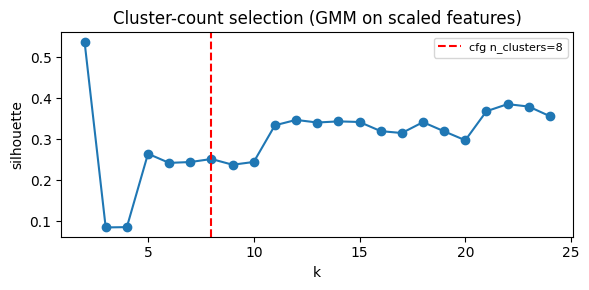

silhouette by k: {2: np.float64(0.539), 3: np.float64(0.085), 4: np.float64(0.086), 5: np.float64(0.265), 6: np.float64(0.243), 7: np.float64(0.245), 8: np.float64(0.252), 9: np.float64(0.238), 10: np.float64(0.245), 11: np.float64(0.334), 12: np.float64(0.348), 13: np.float64(0.341), 14: np.float64(0.344), 15: np.float64(0.343), 16: np.float64(0.32), 17: np.float64(0.316), 18: np.float64(0.342), 19: np.float64(0.32), 20: np.float64(0.298), 21: np.float64(0.369), 22: np.float64(0.386), 23: np.float64(0.38), 24: np.float64(0.357)}


In [6]:
# 5.1 — Silhouette vs k (diagnostic; fit still uses cfg.n_clusters)
ks = range(2, 25)
sil = []
for k in ks:
    gm = GaussianMixture(n_components=k, covariance_type="full", random_state=cfg.random_state)
    gm.fit(X_scaled)
    pred = gm.predict(X_scaled)
    sil.append(silhouette_score(X_scaled, pred, sample_size=min(5000, len(X_scaled)), random_state=cfg.random_state))
plt.figure(figsize=(6, 3))
plt.plot(list(ks), sil, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.axvline(cfg.n_clusters, color="red", ls="--", label=f"cfg n_clusters={cfg.n_clusters}")
plt.title("Cluster-count selection (GMM on scaled features)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_silhouette.pdf", bbox_inches="tight")
plt.show()
print("silhouette by k:", {k: round(s, 3) for k, s in zip(ks, sil)})

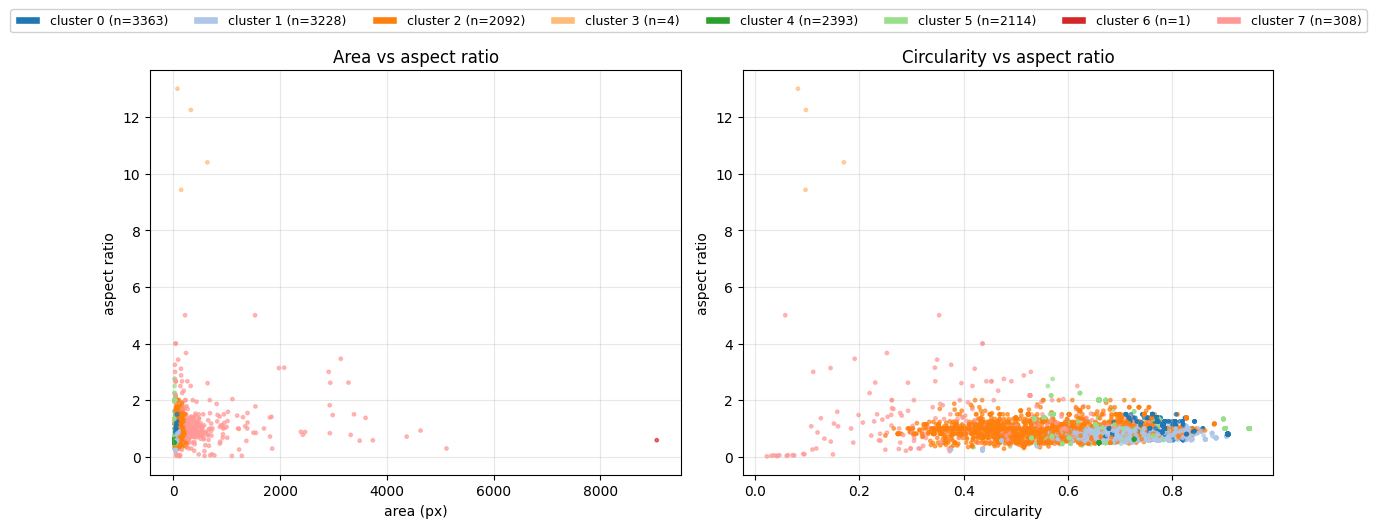

In [7]:
# 5.2 — Extra feature-space scatters

# aspect_ratio = width of box ÷ height of box
# (both in pixels; width is horizontal extent, height is vertical.)
# How to read the aspect ratio:
# 1.0 About as wide as tall (square-ish blob)
# < 1.0 Taller than wide (vertical streak)
# > 1.0 Wider than tall (horizontal streak)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_kw = dict(c=labels, cmap=_discrete_cmap, norm=_bound_norm, alpha=0.65, s=6)
axes[0].scatter(X[:, 0], X[:, 3], **scatter_kw)
axes[0].set_xlabel("area (px)")
axes[0].set_ylabel("aspect ratio")
axes[0].set_title("Area vs aspect ratio")
axes[0].grid(True, alpha=0.3)
axes[1].scatter(X[:, 2], X[:, 3], **scatter_kw)
axes[1].set_xlabel("circularity")
axes[1].set_ylabel("aspect ratio")
axes[1].set_title("Circularity vs aspect ratio")
axes[1].grid(True, alpha=0.3)
legend_handles = [
    Patch(
        facecolor=colors_rgb[c],
        edgecolor="white",
        label=f"cluster {c} (n={int((labels == c).sum())})",
    )
    for c in range(K)
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    
    bbox_to_anchor=(0.5, 1.06),
    ncol=K,
    fontsize=9,
    framealpha=0.9,
)
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_feature_scatters.png", bbox_inches="tight")
plt.show()

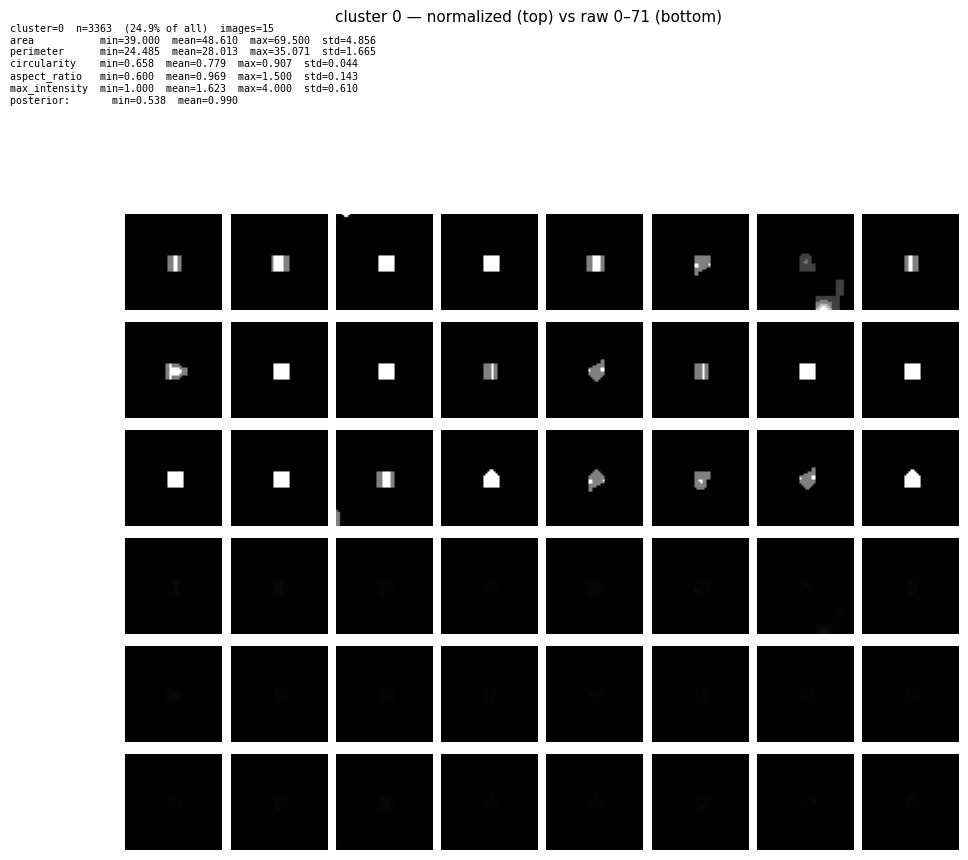

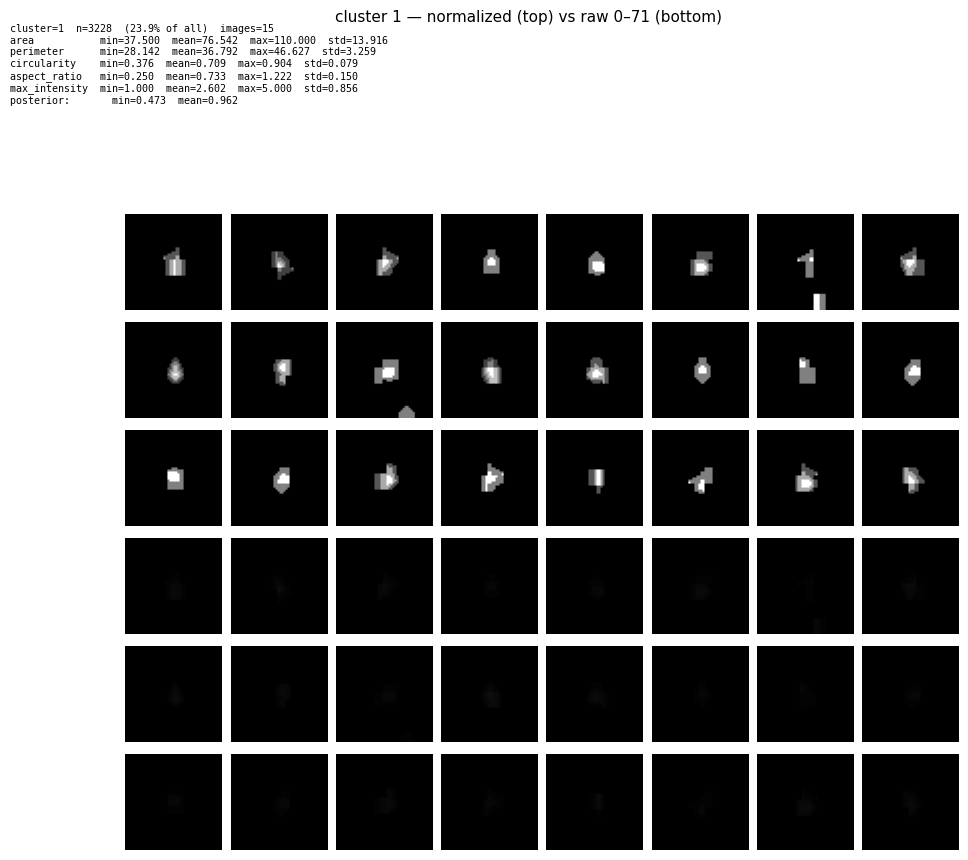

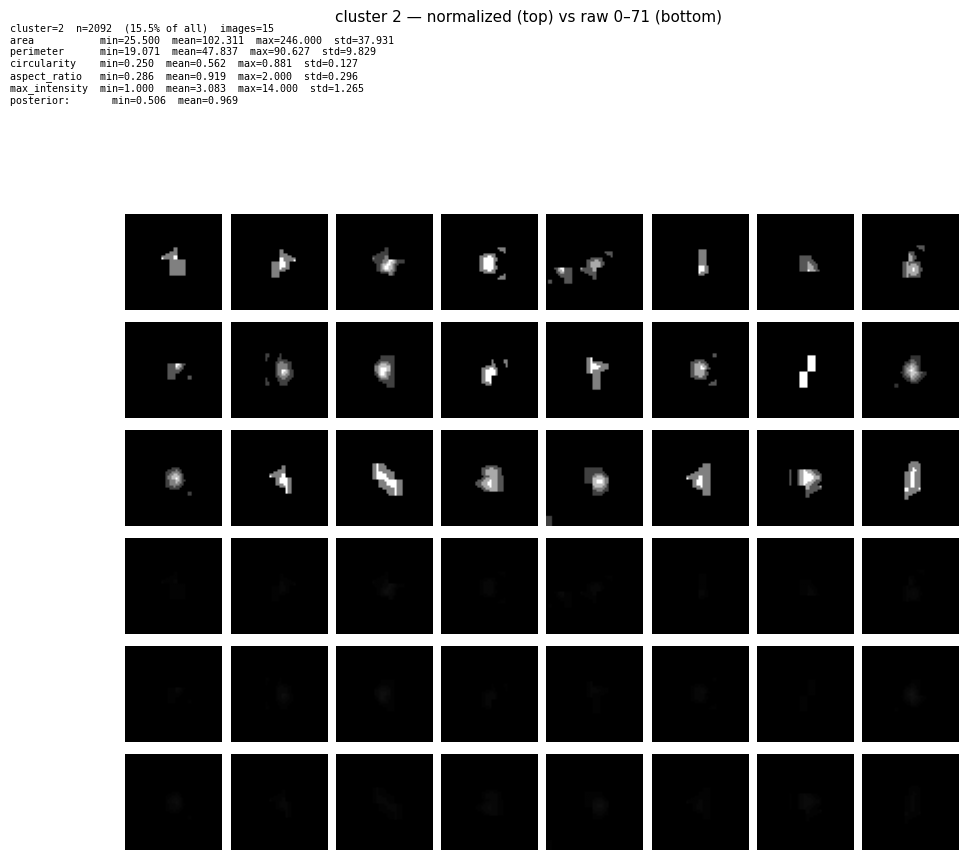

cluster 3: no valid patches for montage


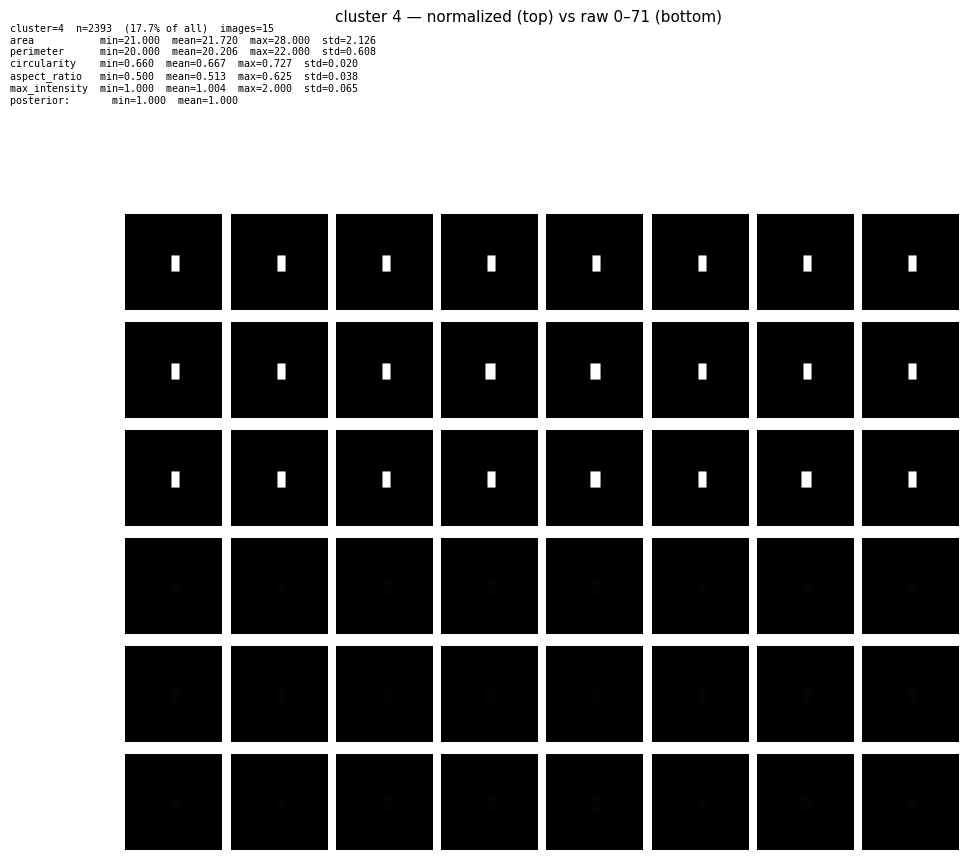

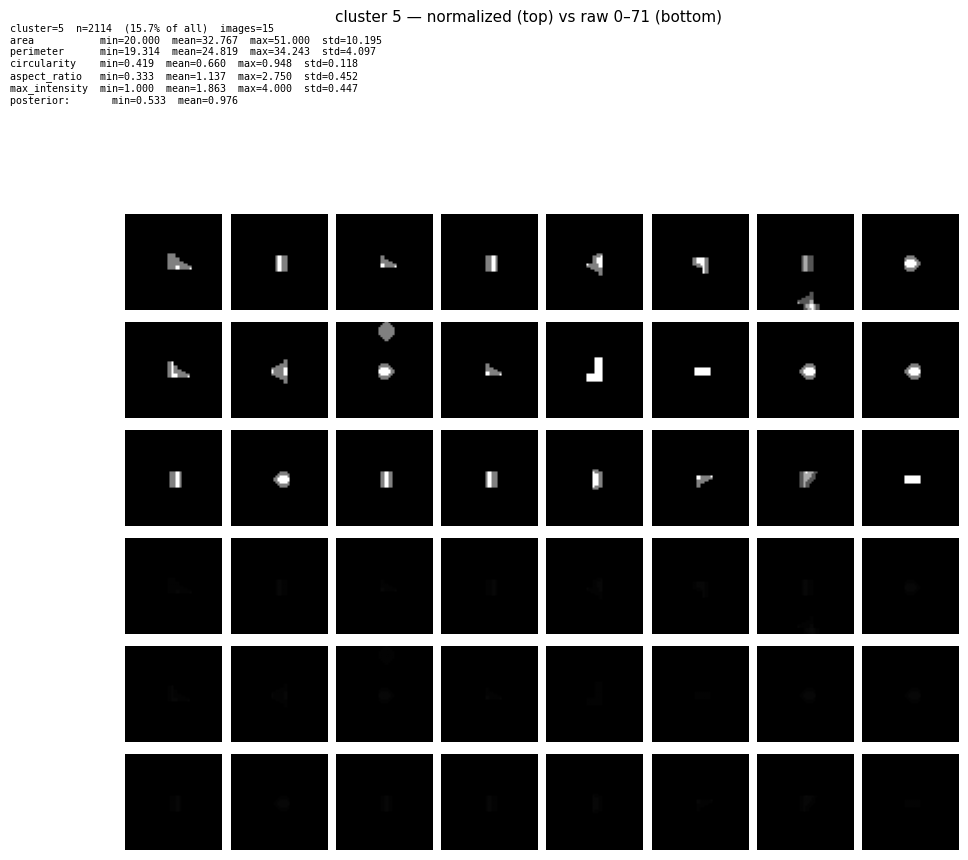

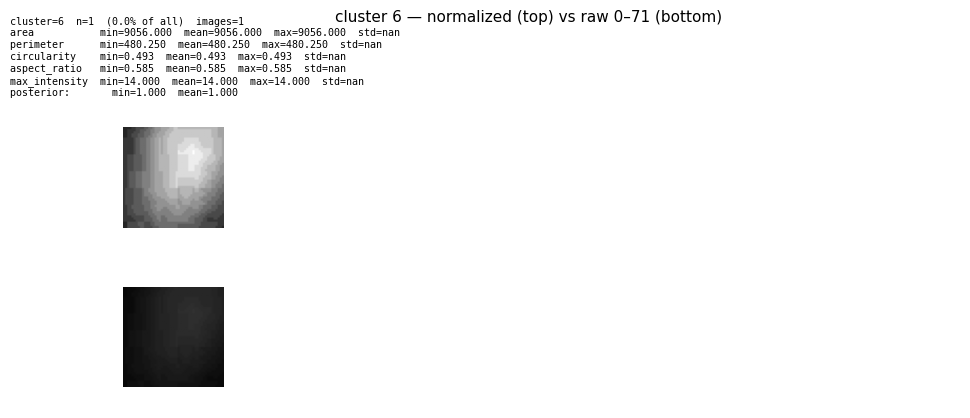

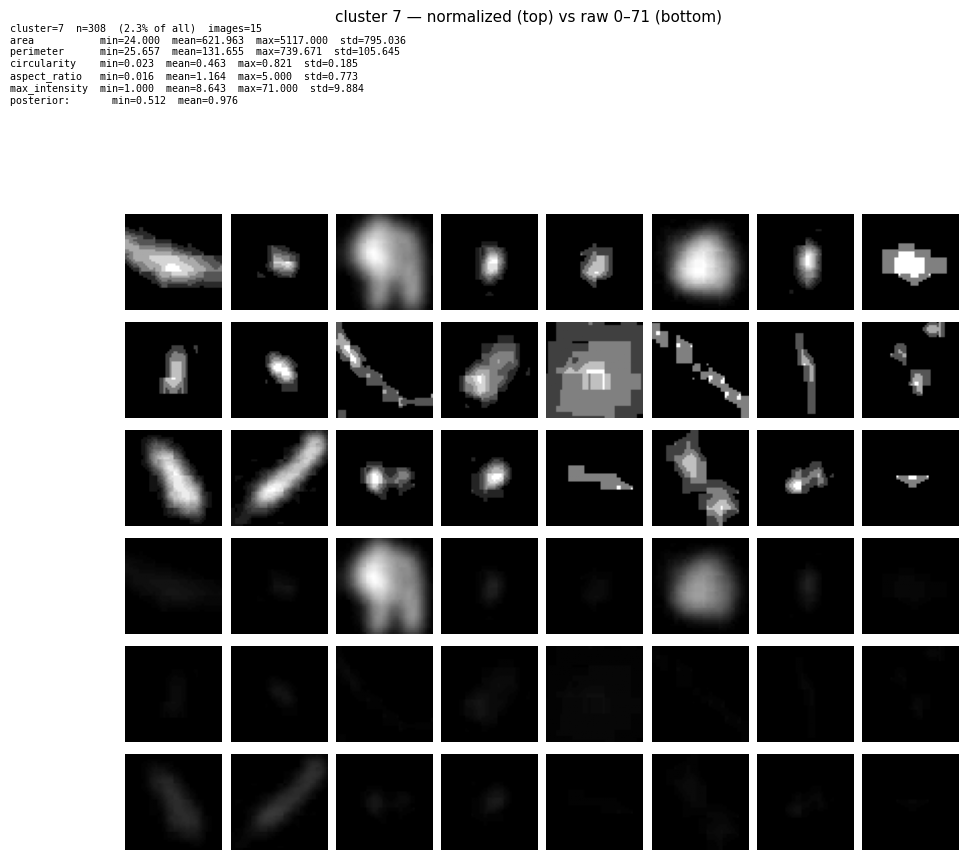

Saved cluster_*.png


In [8]:
# 5.3 — Per-cluster montages (normalized top / raw bottom)

# Posterior is the GMM’s assignment confidence: for each track, 
# the probability that it belongs to the cluster it was assigned to.
# Value	Interpretation
# ≈ 1.0 | Strong, unambiguous assignment
# ≈ 0.5 | Ambiguous — other clusters are similarly likely
# Low min in a cluster | Some members are borderline

def cluster_montage(c, n=MONTAGE_N):
    idx_all = np.where(meta["cluster"].to_numpy() == c)[0]
    idx = idx_all[meta.iloc[idx_all]["patch_valid"].to_numpy()]
    sub = meta.iloc[idx_all]
    stats_txt, stats_row = cluster_stats_block(sub, c)
    if len(idx) == 0:
        print(f"cluster {c}: no valid patches for montage")
        return stats_row
    pick = np.random.choice(idx, min(n, len(idx)), replace=False)
    cols = MONTAGE_COLS
    rows = int(np.ceil(len(pick) / cols))
    fig_h = 2 * rows * 1.25 + 2.0
    fig, axes = plt.subplots(2 * rows, cols, figsize=(cols * 1.35, fig_h))
    axes = np.atleast_2d(axes)
    for ax in np.ravel(axes):
        ax.axis("off")
    for j, gi in enumerate(pick):
        vi = global_to_valid[gi]
        r, col = divmod(j, cols)
        axes[r, col].imshow(patches_norm[vi], cmap="gray", vmin=0, vmax=1)
        axes[rows + r, col].imshow(patches_stack[vi], cmap="gray", vmin=0, vmax=STEP36_RAW_VMAX)
    fig.suptitle(
        f"cluster {c} — normalized (top) vs raw 0–{STEP36_RAW_VMAX} (bottom)",
        fontsize=11,
        y=0.995,
    )
    fig.text(0.02, 0.98, stats_txt, fontsize=7.2, va="top", family="monospace", transform=fig.transFigure)
    plt.subplots_adjust(top=0.78, hspace=0.12, wspace=0.05)
    out = cfg.output_dir / f"cluster_{c}.png"
    fig.savefig(out, dpi=110, bbox_inches="tight")
    plt.show()
    return stats_row

for c in range(K):
    cluster_montage(c)
print("Saved cluster_*.png")

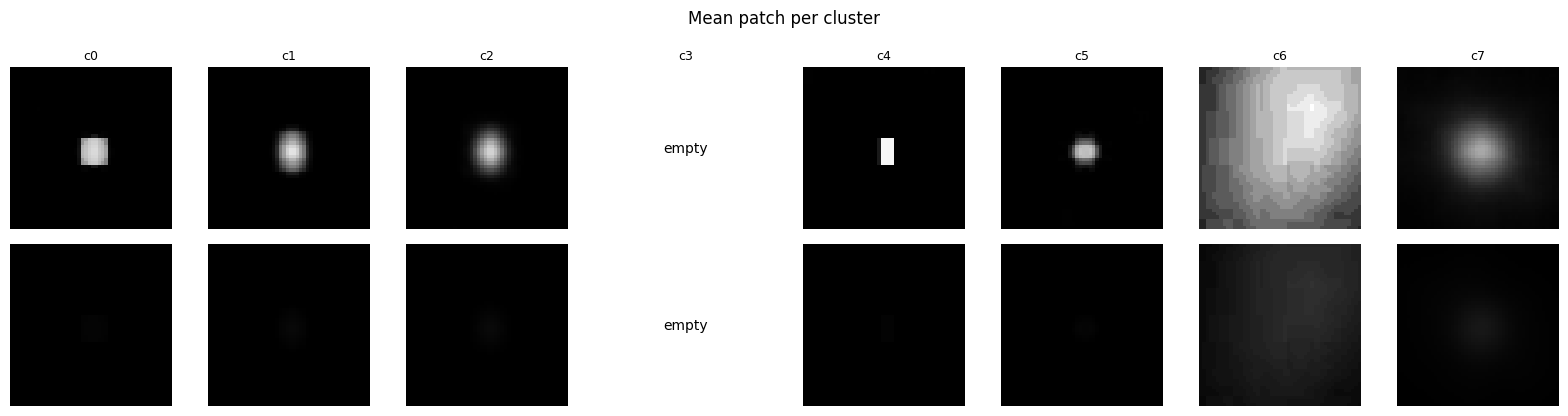

In [9]:
# 5.4 — Mean patch per cluster
fig, axes = plt.subplots(2, K, figsize=(2.0 * K, 4.2))
if K == 1:
    axes = np.array(axes).reshape(2, 1)
for c in range(K):
    idx_all = np.where(meta["cluster"].to_numpy() == c)[0]
    idx = idx_all[meta.iloc[idx_all]["patch_valid"].to_numpy()]
    axes[0, c].set_title(f"c{c}", fontsize=9)
    axes[1, c].axis("off")
    axes[0, c].axis("off")
    if len(idx) == 0:
        axes[0, c].text(0.5, 0.5, "empty", ha="center", va="center")
        axes[1, c].text(0.5, 0.5, "empty", ha="center", va="center")
        continue
    vi = [global_to_valid[gi] for gi in idx]
    norm_mean = patches_norm[vi].mean(axis=0)
    raw_mean = patches_stack[vi].mean(axis=0)
    axes[0, c].imshow(norm_mean, cmap="gray", vmin=0, vmax=1)
    axes[1, c].imshow(raw_mean, cmap="gray", vmin=0, vmax=STEP36_RAW_VMAX)
axes[0, 0].set_ylabel("norm mean", fontsize=9)
axes[1, 0].set_ylabel(f"raw mean\n0–{STEP36_RAW_VMAX}", fontsize=9)
fig.suptitle("Mean patch per cluster")
plt.tight_layout()
fig.savefig(cfg.output_dir / "gmm_cluster_mean_patches.png", dpi=110, bbox_inches="tight")
plt.show()

/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-pack

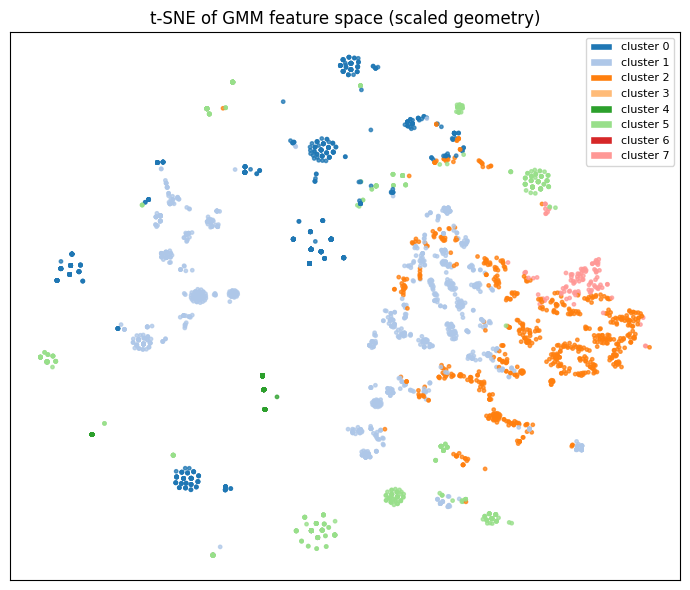

In [10]:
# 5.5 — t-SNE of scaled feature space

# Each dot is one detected track (blob). 
# Its position is not (area, circularity) directly — it’s a 2D embedding 
# built from the 4 scaled GMM features:
# area
# perimeter
# circularity
# aspect ratio

sub_n = min(4000, len(X_scaled))
sidx = np.random.choice(len(X_scaled), sub_n, replace=False)
Zp = PCA(n_components=min(4, X_scaled.shape[1]), random_state=cfg.random_state).fit_transform(X_scaled[sidx])
emb2d = TSNE(n_components=2, perplexity=30, init="pca", random_state=cfg.random_state).fit_transform(Zp)
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    emb2d[:, 0],
    emb2d[:, 1],
    c=meta["cluster"].to_numpy()[sidx],
    cmap=_discrete_cmap,
    norm=_bound_norm,
    s=6,
    alpha=0.75,
)
legend_handles = [
    Patch(facecolor=colors_rgb[c], edgecolor="white", label=f"cluster {c}")
    for c in range(K)
]
plt.legend(handles=legend_handles, loc="best", fontsize=8)
plt.title("t-SNE of GMM feature space (scaled geometry)")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_tsne.pdf", dpi=120, bbox_inches="tight")
plt.show()

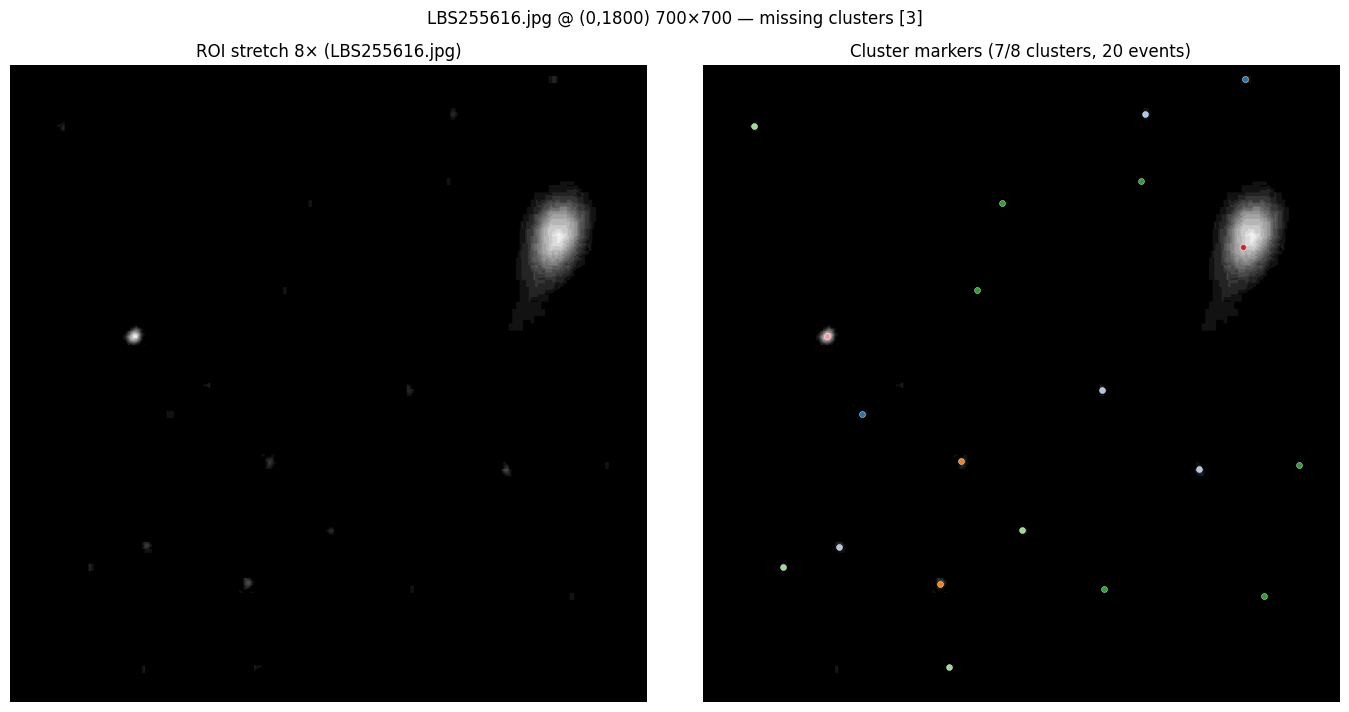

ROI: LBS255616.jpg  x0=0  y0=1800  clusters=[np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]  n=20


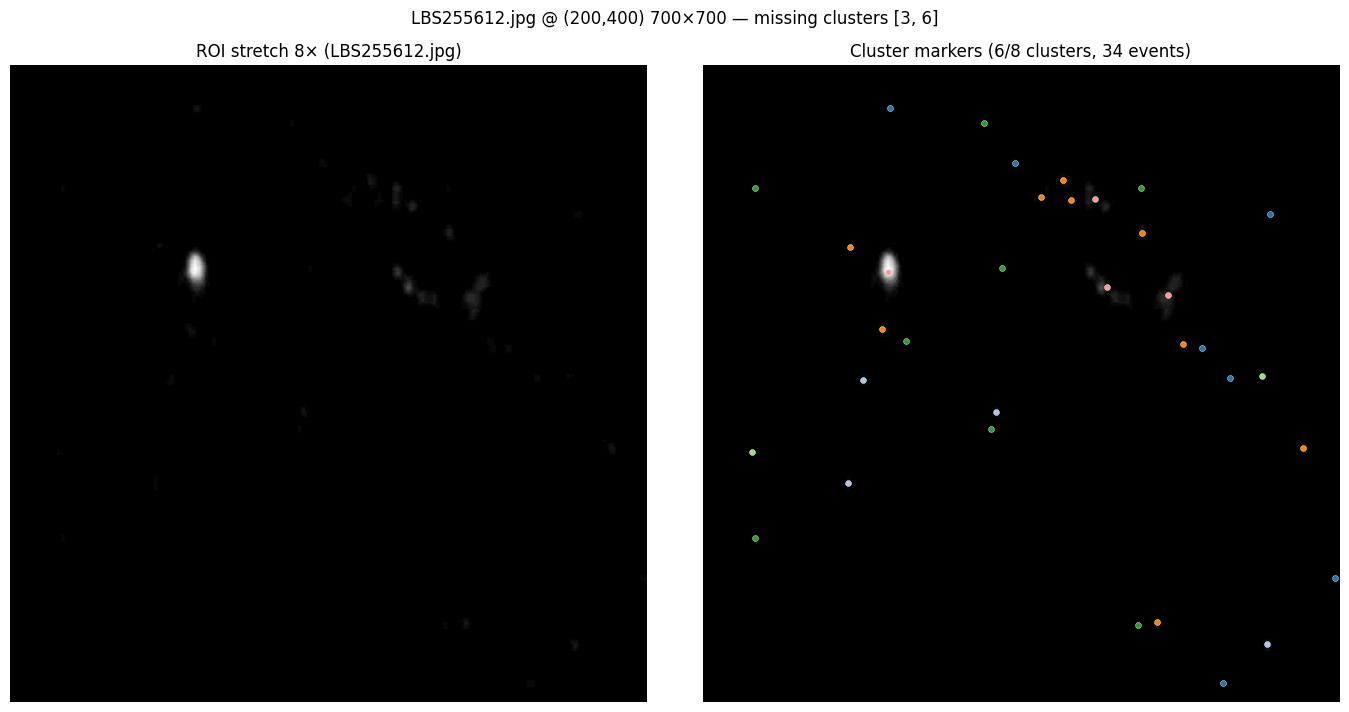

ROI: LBS255612.jpg  x0=200  y0=400  clusters=[np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]  n=34


In [11]:
# 5.6 — Dense ROI window with all clusters visible

def _pick_roi_all_clusters(meta_df, size, grid, n_clusters):
    best = (-1, -1, None, None, None, None)
    roi_lookup = {reg["path"].name: reg["roi"] for reg in image_registry}
    for img_name, grp in meta_df.groupby("image"):
        roi = roi_lookup[img_name]
        H, W = roi.shape
        if H < size or W < size:
            continue
        ys = np.arange(0, H - size, grid)
        xs = np.arange(0, W - size, grid)
        for y0 in ys:
            for x0 in xs:
                mask = (
                    (grp["cx"] >= x0)
                    & (grp["cx"] < x0 + size)
                    & (grp["cy"] >= y0)
                    & (grp["cy"] < y0 + size)
                )
                sub = grp.loc[mask]
                if sub.empty:
                    continue
                n_cl = sub["cluster"].nunique()
                n_cand = len(sub)
                key = (n_cl, n_cand)
                if key > best[:2]:
                    best = (n_cl, n_cand, img_name, int(x0), int(y0), sub)
    return best


def _plot_roi_cluster_window(img_name, x0, y0, size, save_path):
    """Stretch ROI + cluster markers for a fixed window (cross-run comparable)."""
    roi_lookup = {reg["path"].name: reg["roi"] for reg in image_registry}
    if img_name not in roi_lookup:
        print(f"Skip ROI plot: {img_name} not in image_registry")
        return
    roi = roi_lookup[img_name]
    H, W = roi.shape
    if x0 < 0 or y0 < 0 or x0 + size > W or y0 + size > H:
        raise ValueError(
            f"ROI window ({x0},{y0})+{size} out of bounds for {img_name} ({W}×{H})"
        )
    cands = meta.loc[
        (meta["image"] == img_name)
        & (meta["cx"] >= x0)
        & (meta["cx"] < x0 + size)
        & (meta["cy"] >= y0)
        & (meta["cy"] < y0 + size)
    ]
    crop = roi[y0 : y0 + size, x0 : x0 + size]
    stretch = np.clip(crop.astype(int) * 8, 0, 255)
    clusters_present = sorted(cands["cluster"].unique()) if len(cands) else []
    n_cl = len(clusters_present)
    n_cand = len(cands)
    missing = [c for c in range(K) if c not in clusters_present]
    status = "all clusters present" if not missing else f"missing clusters {missing}"

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(stretch, cmap="gray")
    ax[0].set_title(f"ROI stretch 8× ({img_name})")
    ax[0].axis("off")
    ax[1].imshow(stretch, cmap="gray")
    for _, r in cands.iterrows():
        ax[1].scatter(
            r["cx"] - x0,
            r["cy"] - y0,
            s=18,
            c=[colors_rgb[int(r["cluster"])]],
            edgecolors="white",
            linewidths=0.3,
        )
    ax[1].set_title(f"Cluster markers ({n_cl}/{K} clusters, {n_cand} events)")
    ax[1].axis("off")
    fig.suptitle(f"{img_name} @ ({x0},{y0}) {size}×{size} — {status}", y=1.01)
    plt.tight_layout()
    fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"ROI: {img_name}  x0={x0}  y0={y0}  clusters={clusters_present}  n={n_cand}")


best = _pick_roi_all_clusters(meta, ROI_WINDOW, 200, K)
n_cl, n_cand, img_name, x0, y0, _cands = best
if img_name is None:
    raise RuntimeError("No ROI window found for cluster overlay plot")
_plot_roi_cluster_window(
    img_name,
    x0,
    y0,
    ROI_WINDOW,
    cfg.output_dir / "gmm_all_clusters_roi.png",
)

# 5.6b — fixed comparison window (same geometry across runs)
_plot_roi_cluster_window(
    COMPARE_ROI_IMAGE,
    COMPARE_ROI_X0,
    COMPARE_ROI_Y0,
    ROI_WINDOW,
    cfg.output_dir / "gmm_compare_roi_LBS255612.png",
)

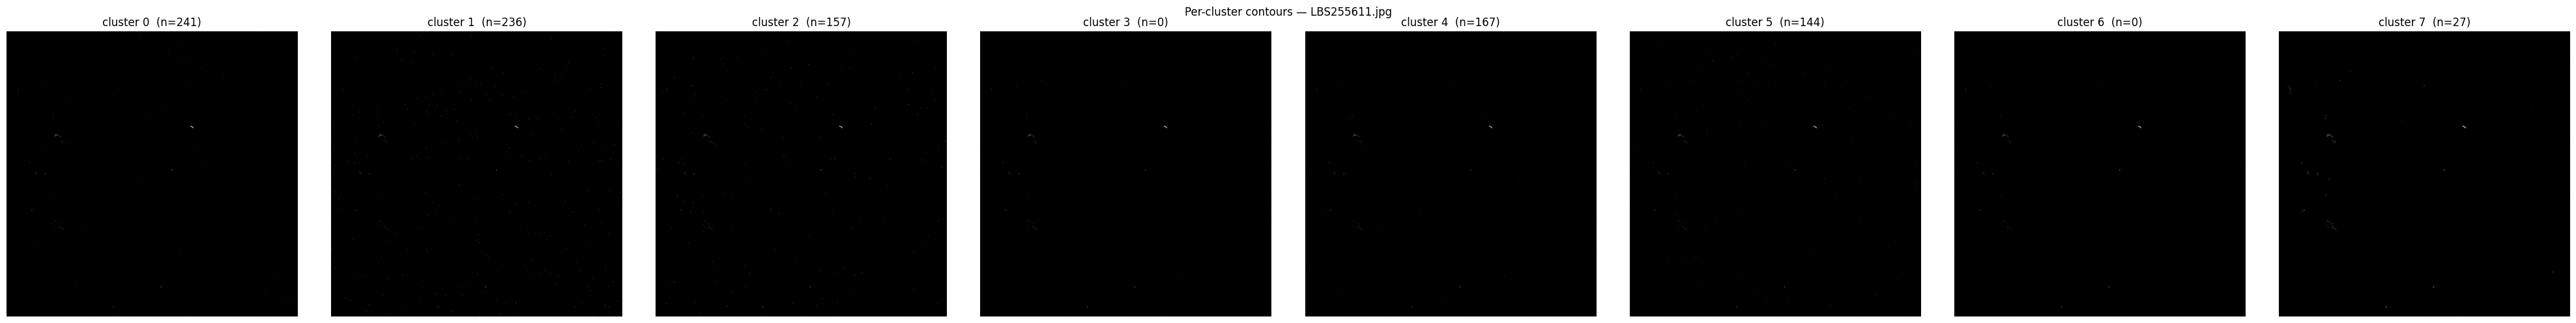

In [12]:
# 5.7 — Per-cluster spatial panels on sample image
if image_registry:
    sample = image_registry[0]
    start = sample["label_start"]
    end = start + sample["counts"]
    sample_labels = labels[start:end]
    roi_norm = cv2.normalize(sample["roi"], None, 0, 255, cv2.NORM_MINMAX)
    fig, axes = plt.subplots(1, K, figsize=(5 * K, 5))
    if K == 1:
        axes = [axes]
    for c in range(K):
        roi_color = cv2.cvtColor(roi_norm, cv2.COLOR_GRAY2BGR)
        for idx, cnt in enumerate(sample["contours"]):
            if sample_labels[idx] != c:
                continue
            cv2.drawContours(roi_color, [cnt], -1, colors_bgr[c], 1)
        n_c = int((sample_labels == c).sum())
        axes[c].imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
        axes[c].set_title(f"cluster {c}  (n={n_c})")
        axes[c].axis("off")
    fig.suptitle(f"Per-cluster contours — {sample['path'].name}")
    plt.tight_layout()
    plt.savefig(cfg.output_dir / "gmm_per_cluster_spatial.pdf", bbox_inches="tight")
    plt.show()